# Apodization

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/FiRMLAB-Pisa/mrutils/blob/main/examples/apodization.ipynb)

`fermi_window`, `hann_window` and `apodize`: trading resolution for a point
spread function without side lobes.

In [1]:
try:
    import mrutils  # noqa: F401
except ImportError:
    %pip install -q "mrutils[torch]" matplotlib

In [2]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

import mrutils as mru


def phantom(n=128):
    """A Shepp-Logan phantom on an n x n grid."""
    y, x = np.mgrid[-1 : 1 : n * 1j, -1 : 1 : n * 1j]
    ellipses = [
        # value, centre x, centre y, semi-axis a, semi-axis b, degrees
        (1.0, 0.0, 0.0, 0.69, 0.92, 0),
        (-0.8, 0.0, -0.0184, 0.6624, 0.874, 0),
        (-0.2, 0.22, 0.0, 0.11, 0.31, -18),
        (-0.2, -0.22, 0.0, 0.16, 0.41, 18),
        (0.1, 0.0, 0.35, 0.21, 0.25, 0),
        (0.1, 0.0, 0.1, 0.046, 0.046, 0),
        (0.1, 0.0, -0.1, 0.046, 0.046, 0),
        (0.1, -0.08, -0.605, 0.046, 0.023, 0),
        (0.1, 0.0, -0.606, 0.023, 0.023, 0),
        (0.1, 0.06, -0.605, 0.023, 0.046, 0),
    ]
    image = np.zeros((n, n))
    for value, cx, cy, a, b, degrees in ellipses:
        angle = np.deg2rad(degrees)
        xr = (x - cx) * np.cos(angle) + (y - cy) * np.sin(angle)
        yr = -(x - cx) * np.sin(angle) + (y - cy) * np.cos(angle)
        image[(xr / a) ** 2 + (yr / b) ** 2 <= 1.0] += value
    return image


# The object is reconstructed on a 128 grid from a 64-wide measurement, which
# is what makes the truncation -- and its ringing -- real rather than nominal.
grid, acquired = 128, 64
image = phantom(grid).astype(complex)
measured = mru.resize_centered(mru.fftc(image), (acquired, acquired))
print(f"acquired {measured.shape}, reconstructed on {image.shape}")

acquired (64, 64), reconstructed on (128, 128)


## Two windows

A reconstruction that transforms a sharply truncated k-space gets the
truncation's ringing with it. An apodization window rolls the measurement off
towards its edge instead, trading resolution for a point spread function
without side lobes.

`fermi_window` sets its radius and its transition width separately, so the
passband stays wide while the roll-off is gentle. `hann_window` is the raised
cosine over the whole radius: it starts tapering at the origin, so it costs
more resolution and leaves less ringing. The table below is that trade, in
numbers.

The point spread functions are evaluated on a grid eight times finer than the
image, and that is not cosmetic: an unwindowed measurement's side lobes fall
exactly on the image grid's sample points, so a PSF read off the image grid
looks side-lobe free when it is nothing of the sort.

In [3]:
fermi = mru.fermi_window((acquired, acquired), radius=0.8, width=0.08)
hann = mru.hann_window((acquired, acquired))
flat = np.ones((acquired, acquired))

upsample = 8


def psf(window):
    """The window's point spread function, on a grid ``upsample`` times finer."""
    fine = mru.resize_centered(
        window.astype(complex), (upsample * acquired, upsample * acquired)
    )
    profile = np.abs(mru.ifftc(fine))[upsample * acquired // 2]
    return profile / profile.max()


offset = (np.arange(upsample * acquired) - upsample * acquired // 2) / upsample

print(f"{'':>6}  {'side lobe':>10}  {'FWHM':>8}")
for label, window in (("none", flat), ("fermi", fermi), ("hann", hann)):
    profile = psf(window)
    lobe = profile[np.abs(offset) > 3].max()
    half = np.flatnonzero(profile > 0.5)
    print(f"{label:>6}  {lobe:>10.1e}  {offset[half[-1]] - offset[half[0]]:>6.2f} px")

         side lobe      FWHM
  none     9.1e-02    1.00 px
 fermi     2.6e-02    1.50 px
  hann     5.6e-03    2.00 px


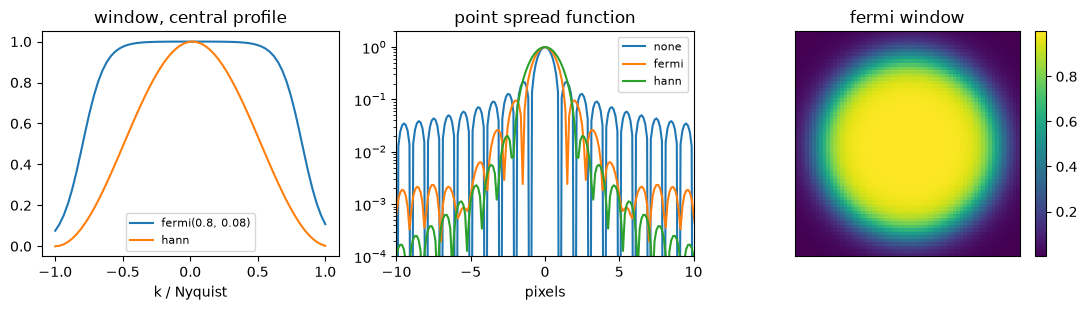

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(11, 3.2))
axes[0].plot(np.linspace(-1, 1, acquired), fermi[acquired // 2], label="fermi(0.8, 0.08)")
axes[0].plot(np.linspace(-1, 1, acquired), hann[acquired // 2], label="hann")
axes[0].set_title("window, central profile")
axes[0].set_xlabel("k / Nyquist")
axes[0].legend(fontsize=8)

for label, window in (("none", flat), ("fermi", fermi), ("hann", hann)):
    axes[1].semilogy(offset, psf(window) + 1e-12, label=label)
axes[1].set_xlim(-10, 10)
axes[1].set_ylim(1e-4, 2)
axes[1].set_title("point spread function")
axes[1].set_xlabel("pixels")
axes[1].legend(fontsize=8)

shown = axes[2].imshow(fermi, cmap="viridis")
axes[2].set_title("fermi window")
axes[2].set_xticks([])
axes[2].set_yticks([])
fig.colorbar(shown, ax=axes[2], fraction=0.046)
fig.tight_layout()

## What it buys

Gibbs ringing is the overshoot at a sharp edge, and more resolution does not
remove it — it only makes it narrower. The profile below crosses the phantom's
skull, which is the sharpest edge in the object.

A window is not a blur: its point spread function has negative lobes, so an
apodized image can still exceed the object's own maximum. What the numbers
show is how much less it does so.

In [5]:
def reconstruct(kspace):
    return mru.ifftc(mru.resize_centered(kspace, (grid, grid)))


truncated = reconstruct(measured)
apodized = reconstruct(mru.apodize(measured, kind="fermi", radius=0.8, width=0.08))
tapered = reconstruct(mru.apodize(measured, kind="hann"))

estimates = (("no window", truncated), ("fermi", apodized), ("hann", tapered))
for label, estimate in estimates:
    over = np.abs(estimate).max() - np.abs(image).max()
    print(f"{label:>10}: overshoot above the object {over:+.3f}")

 no window: overshoot above the object +0.223
     fermi: overshoot above the object +0.117
      hann: overshoot above the object -0.149


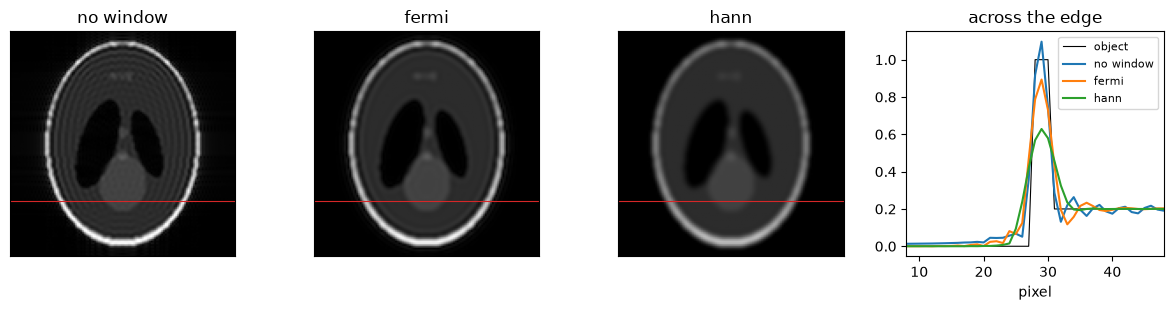

In [6]:
row = 96  # a row crossing the skull, the sharpest edge the object has
fig, axes = plt.subplots(1, 4, figsize=(12, 3.2))
for axis, (label, estimate) in zip(axes[:3], estimates):
    axis.imshow(np.abs(estimate), cmap="gray", vmin=0, vmax=1.15)
    axis.axhline(row, color="tab:red", linewidth=0.8)
    axis.set_title(label)
    axis.set_xticks([])
    axis.set_yticks([])

axes[3].plot(np.abs(image)[row], color="k", linewidth=0.8, label="object")
for label, estimate in estimates:
    axes[3].plot(np.abs(estimate)[row], label=label)
axes[3].set_xlim(8, 48)
axes[3].set_title("across the edge")
axes[3].set_xlabel("pixel")
axes[3].legend(fontsize=8)
fig.tight_layout()

In [7]:
# Written only when the notebook runs inside a clone, and it is what the
# README shows -- so the figure in the README is always this cell's output.
figures = Path("figures")
if figures.is_dir():
    fig.savefig(figures / "apodization.png", dpi=110, bbox_inches="tight")

## Anisotropic matrices

Both windows are radial in *normalized* k, so each axis reaches its own
Nyquist edge at 1. An anisotropic matrix therefore gets an ellipsoid matched
to its own grid rather than a sphere that clips one axis long before the
other.

a (64, 256) matrix gets an ellipse, not a circle


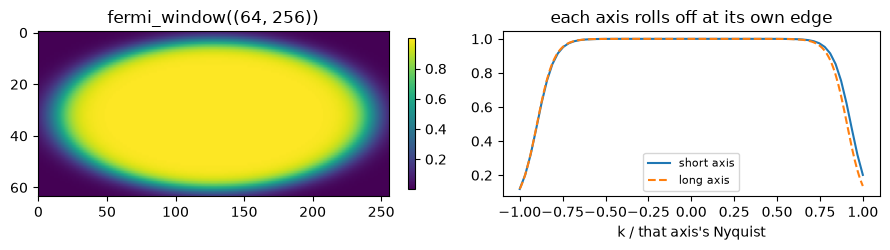

In [8]:
wide = mru.fermi_window((64, 256))
print(f"a {wide.shape} matrix gets an ellipse, not a circle")

fig, axes = plt.subplots(1, 2, figsize=(9, 2.6))
shown = axes[0].imshow(wide, cmap="viridis", aspect="auto")
axes[0].set_title("fermi_window((64, 256))")
fig.colorbar(shown, ax=axes[0], fraction=0.02)
axes[1].plot(np.linspace(-1, 1, 64), wide[:, 128], label="short axis")
axes[1].plot(np.linspace(-1, 1, 256), wide[32], "--", label="long axis")
axes[1].set_xlabel("k / that axis's Nyquist")
axes[1].set_title("each axis rolls off at its own edge")
axes[1].legend(fontsize=8)
fig.tight_layout()